## Data Exploaration
In this section, we will perform data exploration and determine the factors responsible for the price of a house. We have gathered data from the following link
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

## Research Question
1. Do different factors can really decide the price of a house or not?
2. Do the missing variables present in the data really affect the relation between the factors and the saleprice?

## Import of data and libraries

In [1]:
import pandas as pd #used for data manipulation
import numpy as np # used for numeric imputation

import matplotlib.pyplot as plt # used for visualization
import io
import requests
# to show all the columns of the dataframe in the notebook
pd.set_option('display.max_columns', None)

# First, we will import the data to look into the nature of the data and perform different analysis

In [2]:
# let's load the House Prices dataset
# and explore its shape (rows and columns)
data=pd.read_csv(io.StringIO(requests.get("https://raw.githubusercontent.com/VenkatMurukuti/Project2/main/houseprice.csv").content.decode('utf-8')))
data.shape #shape 

(1460, 81)

In [3]:
data_viz=data.copy() #make a copy for future use

# Initially, the data contain 1460 rows and 81 columns

In [4]:
# let's visualise the dataset
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Missing Value Exploration
In this section, we will find out the number of missing values present in the data.

In [5]:
# find the variables with missing observations

vars_with_na = [var for var in data.columns if data[var].isnull().mean() > 0]
vars_with_na

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

## Nature of the Data

In [6]:
# let's find out whether they are numerical or categorical
data[vars_with_na].dtypes

LotFrontage     float64
Alley            object
MasVnrType       object
MasVnrArea      float64
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Electrical       object
FireplaceQu      object
GarageType       object
GarageYrBlt     float64
GarageFinish     object
GarageQual       object
GarageCond       object
PoolQC           object
Fence            object
MiscFeature      object
dtype: object

# There are both numerical and categorical variables with missing observations. We can see from the variable types that some are float and some are object.

In [7]:
# let's have a look at the values of the variables with
# missing data

data[vars_with_na].head(10)

,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,None,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,None,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN
5,85.0,NaN,None,0.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,1993.0,Unf,TA,TA,NaN,MnPrv,Shed
6,75.0,NaN,Stone,186.0,Ex,TA,Av,GLQ,Unf,SBrkr,Gd,Attchd,2004.0,RFn,TA,TA,NaN,NaN,NaN
7,NaN,NaN,Stone,240.0,Gd,TA,Mn,ALQ,BLQ,SBrkr,TA,Attchd,1973.0,RFn,TA,TA,NaN,NaN,Shed
8,51.0,NaN,None,0.0,TA,TA,No,Unf,Unf,FuseF,TA,Detchd,1931.0,Unf,Fa,TA,NaN,NaN,NaN
9,50.0,NaN,None,0.0,TA,TA,No,GLQ,Unf,SBrkr,TA,Attchd,1939.0,RFn,Gd,TA,NaN,NaN,NaN


# Some columns contain lot of missing variables while some contain less missing variablels. Let us look into the percentage of missing variables present in the data

In [8]:
# let's find out the percentage of observations missing per variable

# calculate the percentage of missing (as we did in section 3)
# using the isnull() and mean() methods from pandas
data_na = data[vars_with_na].isnull().mean()

# transform the array into a dataframe
data_na = pd.DataFrame(data_na.reset_index())

# add column names to the dataframe
data_na.columns = ['variable', 'na_percentage']

# order the dataframe according to percentage of na per variable
data_na.sort_values(by='na_percentage', ascending=False, inplace=True)

# show
data_na

,variable,na_percentage
16,PoolQC,0.995205
18,MiscFeature,0.963014
1,Alley,0.937671
17,Fence,0.807534
10,FireplaceQu,0.472603
0,LotFrontage,0.177397
11,GarageType,0.055479
12,GarageYrBlt,0.055479
13,GarageFinish,0.055479
14,GarageQual,0.055479


# The first 6 variables contain a lot of missing information.
I will ignore the first 6 variables with a lot of missing data, and proceed with the exploration in the remaining of the dataset.

In [9]:
# capture variables with no or less than 5% NA

vars_cca = [var for var in data.columns if data[var].isnull().mean() < 0.05]
vars_cca

['Id',
 'MSSubClass',
 'MSZoning',
 'LotArea',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SaleType',
 'SaleCond

In [10]:
data=data[vars_cca] #considering only those data that contain no or less than 5 missing values

In [11]:
data.drop(['Id'],inplace=True,axis=1)

In [12]:
data

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,2,548,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,2,460,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,2,608,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,3,642,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,3,836,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,2,460,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,2,500,Y,349,0,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,1,252,Y,0,60,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,1,240,Y,366,0,112,0,0,0,0,4,2010,WD,Normal,142125


# Now the data contain only  69 columns after removing the columns which have more than 5% missing values

# Data preprocessing

### 1. Missing values imputation

The only numeric column that has missing value is 'MasVnrArea'. So we will fill them with mean values

In [13]:
data['MasVnrArea'].isnull().sum()

8

# Out of 1460 rows, only 8 values are missing from the data. So we can replace it with the mean data.

In [14]:
data['MasVnrArea']= data['MasVnrArea'].fillna(data['MasVnrArea'].mean())


In [15]:
data['MasVnrArea'].isnull().sum() #now we hav filled all the 8 values with mean value

0

### 2. Categorical values imputation
Since lot of categorical variables contain missing variables, we will fill them with ode values. 

In [16]:
# Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)

Categorical variables:
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']


In [17]:
data[object_cols].isnull().sum()

MSZoning          0
Street            0
LotShape          0
LandContour       0
Utilities         0
LotConfig         0
LandSlope         0
Neighborhood      0
Condition1        0
Condition2        0
BldgType          0
HouseStyle        0
RoofStyle         0
RoofMatl          0
Exterior1st       0
Exterior2nd       0
MasVnrType        8
ExterQual         0
ExterCond         0
Foundation        0
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Heating           0
HeatingQC         0
CentralAir        0
Electrical        1
KitchenQual       0
Functional        0
PavedDrive        0
SaleType          0
SaleCondition     0
dtype: int64

# Out of all the categorical variables, we have found 7 categorical variables that contain the missing values. We will perform mode imputation on them

In [18]:
data['MasVnrType'].fillna(data['MasVnrType'].mode()[0], inplace=True)
data['BsmtQual'].fillna(data['BsmtQual'].mode()[0], inplace=True)
data['BsmtCond'].fillna(data['BsmtCond'].mode()[0], inplace=True)
data['BsmtExposure'].fillna(data['BsmtExposure'].mode()[0], inplace=True)
data['BsmtFinType1'].fillna(data['BsmtFinType1'].mode()[0], inplace=True)
data['BsmtFinType2'].fillna(data['BsmtFinType2'].mode()[0], inplace=True)
data['Electrical'].fillna(data['Electrical'].mode()[0], inplace=True)

In [19]:
data[object_cols].isnull().sum()

MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

# Now our data is ready and we will explore more to solve our research questions

# 1. Correlation
Correlation is used to look into the relationship existing between two variables. With the help of visualization, we can see correlation with the help of heatmap. Since our research question is to investigate whether the house price is affected by other factors, Let us look into the correlation between different variables with the help of heatmap

In [20]:
import seaborn as sns

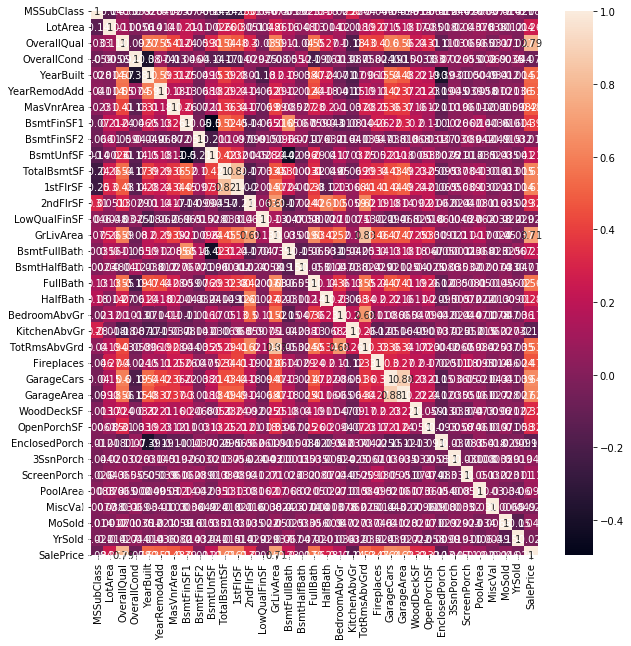

In [21]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)
plt.show()

# With the heatmap, it is not possible to see clearly as the data contain too many features. So we will select the 10 most important features highly correlated to sale price of a house

In [22]:
f=pd.Series(abs(pd.get_dummies(data).corr()['SalePrice']).sort_values(ascending=False))
f.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
ExterQual_TA    0.589044
FullBath        0.560664
BsmtQual_Ex     0.553105
Name: SalePrice, dtype: float64

# From the correlation, we found features like 'OverallQual','GrLivArea','GarageCars','GarageArea' are highly correlated with the Sale price. We will also perform other feature selection techniques to confirm the same

# For other feature importance, we need to perform label encoding to the categorical variables and feed into a machine learning model. XGBoost is suitable as it has inbuilt feature selection methods where we can understand the most significant factors responsible for the sale price of a house

In [23]:
from sklearn.preprocessing import LabelEncoder #label encoder library
from sklearn.preprocessing import OrdinalEncoder #label encoder library


In [24]:
X=data.drop(['SalePrice'],axis=1) #select features
y=data['SalePrice'] #select target

In [25]:
object_cols= [cname for cname in X.columns if 
                    X[cname].dtype == "object"] #select categorical variables

In [26]:
#ordinal encoder which will change all categorical variables to 0,1,2,etc
ordinal_encoder = OrdinalEncoder()
X[object_cols] = ordinal_encoder.fit_transform(X[object_cols])

/opt/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:110: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X_int = np.zeros((n_samples, n_features), dtype=np.int)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:111: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more de

In [27]:
#splitting the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
#XGBoost regressor which is important for permutation importance
!pip3 install xgboost
from xgboost import XGBRegressor
import xgboost as xg
model_XGB=XGBRegressor()

In [29]:
model_XGB.fit(X_train,y_train) #fitting data

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=4,
             num_parallel_tree=1, objective='reg:squarederror',
             predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
             scale_pos_weight=1, subsample=1, tree_method='exact',
             validate_parameters=1, verbosity=None)

## 2. Permutation Importance

In [30]:
!pip install eli5
import eli5 
from eli5.sklearn import PermutationImportance

ImportError: cannot import name 'soft_unicode' from 'markupsafe' (/opt/anaconda3/lib/python3.7/site-packages/markupsafe/__init__.py)

In [ ]:
perm = PermutationImportance(model_XGB, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names = X_test.columns.tolist())

From the analysis, we can see that the features like GrLivArea,OverallQual,GarageCars are the most important factors to decide the price of a house

# 2nd Hypothesis :
we need to see if missing values affect the relation between the factors and the sale price of a house.
For that,we will drop all the missing values from the data to see the if the most important factors show less correlation or not.

In [ ]:
data_null = pd.read_csv('https://raw.githubusercontent.com/VenkatMurukuti/Project2/main/houseprice.csv') #importing the data


In [ ]:
data_null=data_null[vars_cca] #considering only those data that contain no or less than 5 missing values

In [ ]:
data_null.drop(['Id'],inplace=True,axis=1) #dropping the ID column which is not required

In [ ]:
data_null=data_null.dropna() #dropping all the missing variables

In [ ]:
data_null

# Now we can see we are left with only 1412 rows. Let us see the correlation now with the Sale Price

## 1. Correlation (After dropping of missing values)

In [ ]:
f=pd.Series(abs(pd.get_dummies(data_null).corr()['SalePrice']).sort_values(ascending=False))
f.head(10)

The correlation of OverallQual seems to be affected after dropping the missing rows from the data.

## 2. Permutation Importance (After dropping of missing values)

In [ ]:
X=data_null.drop(['SalePrice'],axis=1) #select features
y=data_null['SalePrice'] #select target

In [ ]:
object_cols= [cname for cname in X.columns if 
                    X[cname].dtype == "object"]

In [ ]:
ordinal_encoder = OrdinalEncoder()
X[object_cols] = ordinal_encoder.fit_transform(X[object_cols])

In [ ]:
#splitting the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from xgboost import XGBRegressor
model_XGB=XGBRegressor()

In [ ]:
model_XGB.fit(X_train,y_train) #fitting data

In [ ]:
perm = PermutationImportance(model_XGB, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names = X_test.columns.tolist())

# From the analysis after dropping the missing values, we can see many important factors like GarageCars and TOtalBsmtSF dropped their weights. Also the correlation between them got affected.
So we can say that missing values affect the relation between explanatory variables and the sale price of a house

## Final Analysis
From the analysis of correlation, we have observed the correlation value of OverallQual decreased after dropping the missing value. Also from the permutation importance, we have seen that weights of the columns like TotalBsmtSF increased and GarageCars decreased which indicates the dropping of missing variables affects the relation between the features and the outcome.

## Visualization of important factors
We have seen that features like OverallQual, GrLivArea, GarageCars, GarageArea are important factors to decide the sale price of a house. Let us visualize them to confirm the same

### Overall Quality vs Saleprice

In [ ]:
import seaborn as sns
ax = sns.barplot(x="OverallQual", y="SalePrice", data=data_viz)
plt.title("OverallQuality vs SalePrice")

# From the graph, it is evident that the house which has good quality has more sale price. So OverallQual decides the sale price of a house

### GrLivArea VS SalePrice

In [ ]:
data_viz['GrLivArea']

In [ ]:
sns.scatterplot(data=data_viz, x="GrLivArea", y="SalePrice")
plt.title("GrLivArea VS SalePrice")

# From the graph above, we can see that the sale price of the house increases with the increase of GrLivArea. So we can say GrLivArea plays an important role in deciding the sale prie of a house

### Garage Area vs SalePrice

In [ ]:
sns.scatterplot(data=data_viz, x="GarageArea", y="SalePrice")
plt.title("GarageArea VS SalePrice")

# From the scatterplot above,we can say that sale price of a house increases if the garage area of a house is more. This is not the same case for everyhouse which is why it is  moderately correlated to each other.

### Garage Cars vs SalePrice

In [ ]:
ax = sns.barplot(x="GarageCars", y="SalePrice", data=data_viz)
plt.title("Garage Cars vs SalePrice")

# We can see, that the house which have a car space of 3 or more are higher in price. And the house with no garage are lower in price. So GarageCars decides the sale price of a house

### TotalBsmtSf vs SalePrice

In [ ]:
sns.scatterplot(data=data_viz, x="TotalBsmtSF", y="SalePrice")
plt.title("TotalBsmtSF VS SalePrice")

# From the plot, TotalBsmtSF is also positively correlated with the sale price of a house. So it also makes an important factor to decide the sale price of a house.

# Conclusion

From the final research analysis, we have found the following <br><br> 1.Do different factors can really decide the price of a house or not? <br><br> Yes <br><br> Features like OverallQuality, TotalBsmtSF, GrLivArea, Garagearea, Garagecars are the significant factors to decide the sale price of a  house. <br><br> 2.Do the missing variables present in the data really affect the relation between the factors and the saleprice? <br><br>  Yes <br><br> This is found from the correlation and the permutation importance.